# Proyecto Final — Módulo 6

## Tema: Población adulta estadounidense (1994) con ingreso anual > $50K USD

| **Campo** | **Detalle** |
|---|---|
| **Grupo** | 2 |
| **Integrantes** | Cinthia Montero, Sebastián Calvo |
| **Curso** | Ciencia de Datos |
| **Fecha de Entrega** | 04 Setiembre 2026 |

---


### **Problema:**  
### Averigüar las características de la poblacióna adulta estadounidense del año 1994 que tenía ingresos anuales mayores a $ 50K USD y predecir sus futuros comportamientos.

### **Objetivo:**
### Identificar características que sean claves para determinar patrones que desarrollen individuos de la población que generen un ingreso anual mayor a $ 50K USD.

# **ETAPAS :**

# 2. Ingesta

In [ ]:
# Librerías para manipulación y análisis de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Permite visualizar todas las columnas del DataFrame
pd.set_option('display.max_columns', None)

import os
os.environ["OMP_NUM_THREADS"] = "5"

In [13]:
# Instalamos 

!pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Descargamos dataset de https://archive.ics.uci.edu/dataset/2/adult?utm_source=chatgpt.com

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

# 3. Data Quality

## 3.1 Identificación de valores, tipos de dato y dimensionalidad:

Primeramente identificamos valores faltantes, simbolos insuales, tipos de dato incongrüentes y valores nulos.

Para este caso en particular al tratarse de un Censo se asume que los valores ya fueron previamente revisados y no se estan duplicando datos. Este dataset no cuenta con alguna columna con datos de identificación ó datos singulares y únicos que permitan confirmar que la información no es duplicada.  No obstante se hace una revisión para hacer constar el peso de los datos duplicados sobre el total del dataset.


### 3.1.1 Facilitamos visualización:

In [4]:
# Redondeamos a dos decimales
pd.set_option('display.float_format', '{:.2f}'.format)

In [5]:
# Visualizamos las 5 filas para validación

df = pd.concat([X, y], axis=1)
display(df.sample(5))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
3247,64,Self-emp-inc,132832,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,20051,0,40,?,>50K
11101,67,Self-emp-not-inc,195066,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
471,22,?,139883,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
11653,29,Private,232784,Assoc-acdm,12,Never-married,Exec-managerial,Own-child,White,Male,0,0,40,United-States,<=50K
2784,61,Private,43554,5th-6th,3,Never-married,Handlers-cleaners,Not-in-family,Black,Male,0,2339,40,United-States,<=50K


### 3.1.2 Dimensiones y nombre de columnas del dataset:

In [6]:
# Dimensiones del dataset

print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")    # cantidad de filas y columnas

El dataset contiene 48842 filas y 15 columnas.


In [7]:
# Nombres de las columnas del dataset
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

### 3.1.3 Tipos de Datos Generales

In [8]:
# Información general y tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


### 3.1.4 Tipos de Datos Específicos

Muestra el control sobre el tipo de dato cuantitativo o cualitativo de forma más específica para este dataset.

In [9]:
def detectar_tipo(serie):
    if pd.api.types.is_bool_dtype(serie):
        return 'Cualitativa - booleana (bool)'
    elif serie.nunique(dropna=True) == 2:
        return 'Cualitativa - binaria'
    elif pd.api.types.is_integer_dtype(serie):
        return 'Cuantitativa - entera (int)'
    elif pd.api.types.is_float_dtype(serie):
        return 'Cuantitativa - decimal (float)'
    elif isinstance(serie.dtype, pd.CategoricalDtype):
        return 'Cualitativa - categórica (' + ('ordinal' if serie.cat.ordered else 'nominal') + ')'
    elif pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie):
        return 'Cualitativa - categórica (texto)'
    else:
        return f'Otro ({serie.dtype})'

resumen_tipos = pd.DataFrame({
    'Dtype (pandas)':  df.dtypes.astype(str),
    'Non-Null Count':  df.notnull().sum(),
    'Valores únicos':  df.nunique(),
    'Tipo detectado':  [detectar_tipo(df[c]) for c in df.columns],
})
resumen_tipos

,Dtype (pandas),Non-Null Count,Valores únicos,Tipo detectado
age,int64,48842,74,Cuantitativa - entera (int)
workclass,str,47879,9,Cualitativa - categórica (texto)
fnlwgt,int64,48842,28523,Cuantitativa - entera (int)
education,str,48842,16,Cualitativa - categórica (texto)
education-num,int64,48842,16,Cuantitativa - entera (int)
marital-status,str,48842,7,Cualitativa - categórica (texto)
occupation,str,47876,15,Cualitativa - categórica (texto)
relationship,str,48842,6,Cualitativa - categórica (texto)
race,str,48842,5,Cualitativa - categórica (texto)
sex,str,48842,2,Cualitativa - binaria


## 3.2 Valores Duplicados 

In [10]:
# Se eliminan 48 filas duplicadas exactas 
filas_antes = df.shape[0]
df = df.drop_duplicates()
filas_despues = df.shape[0]

print(f'Filas eliminadas por duplicado exacto: {filas_antes - filas_despues}')
print(f'Filas totales luego de eliminar duplicados: {filas_despues}')



Filas eliminadas por duplicado exacto: 29
Filas totales luego de eliminar duplicados: 48813


### Hallazgos sobre valores duplicados:

Se encuentran 48 filas que parecen ser duplicadas. En un primer momento se decidió conservarlas, ya que no se contaba con evidencia suficiente para determinar si eran errores de captura o registros legítimamente idénticos. Sin embargo, al llegar al análisis de Leakage (sección 3.7.8) se identificó que conservarlas representa un riesgo de fuga de datos entre train y test al hacer el split para el modelado. Por esa razón se revisa la decisión inicial y se eliminan las 48 filas duplicadas.

## 3.3 Valores Nulos

Se valida la existencia de valores nulos, revisamos tanto el formato del valor nulo convertido mediante repositorio **ucimlrepo** como también su formato original.

Detectamos que la librería de origen no normalizó el símbolo de faltante de forma consistente, por lo que unificamos ambas codificaciones antes de continuar.

Revisaremos la existencia de los siguientes símbolos que representan en este dataset valores nulos ó faltantes: "NaN", "?" y " ".

In [11]:
# Cantidad de nulos por columna
df.isnull().sum()

# Solo las columnas que sí tienen nulos, con porcentaje
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pd.DataFrame({
    'Valores faltantes': nulos,
    'Porcentaje (%)': (nulos / len(df) * 100).round(2)
})

,Valores faltantes,Porcentaje (%)
occupation,966,1.98
workclass,963,1.97
native-country,274,0.56


In [12]:
# Verificación de nulos en formato original de dataset.

(df == '?').sum()[lambda x: x > 0]

workclass         1836
occupation        1843
native-country     582
dtype: int64

In [13]:
# Busca strings vacíos o que son solo espacios en las columnas de texto
cols_obj = df.select_dtypes(include='object').columns

vacios = {}
for col in cols_obj:
    n = (df[col].astype(str).str.strip() == '').sum()
    if n > 0:
        vacios[col] = n

print('Columnas con celdas vacías/solo espacios:', vacios or 'ninguna')

Columnas con celdas vacías/solo espacios: ninguna


C:\Users\c3283\AppData\Local\Temp\ipykernel_2996\623287439.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_obj = df.select_dtypes(include='object').columns


In [14]:
nulos_nan = df.isnull().sum()
nulos_signo = (df == '?').sum()
total_faltantes = nulos_nan.add(nulos_signo, fill_value=0)
total_faltantes = total_faltantes[total_faltantes > 0].sort_values(ascending=False)
pd.DataFrame({
    'Valores faltantes': total_faltantes.astype(int),
    'Porcentaje (%)': (total_faltantes / len(df) * 100).round(2)
})

,Valores faltantes,Porcentaje (%)
occupation,2809,5.75
workclass,2799,5.73
native-country,856,1.75


In [27]:
pd.set_option('display.max_columns', None)

df[df[['workclass','occupation','native-country']].isnull().any(axis=1) |
   (df[['workclass','occupation','native-country']] == '?').any(axis=1)].sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
9500,27,?,180553,HS-grad,9,Married-civ-spouse,?,Wife,White,Female,0,0,40,United-States,>50K
40346,46,NaN,427055,Some-college,10,Divorced,NaN,Not-in-family,White,Male,0,0,40,United-States,>50K.
45966,59,NaN,43103,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K.
28476,71,?,116165,Some-college,10,Widowed,?,Not-in-family,White,Female,0,0,14,Canada,<=50K
37940,74,NaN,132112,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,48,United-States,<=50K.


### Hallazgos de valores faltantes: 

Se encuentran 6,465 celdas con valores nulos. Sin embargo por categoría los valores nulos representan aproximadamente entre un 5% y un 6% para las columnas de "occupation" y "worldclass", y para la columna "native-country" este representa apenas un 1.75%.   

## 3.4 Imputación

Debido a los valores faltantes representan aproximadamente un 5% aproximadamente ó inclusive un valor menor del total de cada columna y a la vez al tratarse de datos de tipo cualitativos, **imputaremos con base en la moda**.

#### Calculo de la Moda:

In [28]:
cols_con_nulos = ['workclass', 'occupation', 'native-country']

# Moda de cada columna (ignora nulos y "?")
modas = {}
for col in cols_con_nulos:
    moda = df.loc[~df[col].isnull() & (df[col] != '?'), col].mode()[0]
    modas[col] = moda
    print(f'{col}: moda = {moda}')

workclass: moda = Private
occupation: moda = Prof-specialty
native-country: moda = United-States


In [29]:
# Imputación: reemplaza NaN y "?" por la moda de cada columna
df_clean = df.copy()

for col in cols_con_nulos:
    df_clean[col] = df_clean[col].replace('?', modas[col])
    df_clean[col] = df_clean[col].fillna(modas[col])

# Verificación
print(df_clean[cols_con_nulos].isnull().sum())
print((df_clean[cols_con_nulos] == '?').sum())

workclass         0
occupation        0
native-country    0
dtype: int64
workclass         0
occupation        0
native-country    0
dtype: int64


### 3.4.1 Eliminación de un caractér:  punto (.) en columna "income"

Al eliminar el punto que se presenta en algunas de las filas de la columna income se logra limpiar los datos en estas quedando en solo dos categorías la varaible income.

In [30]:
df_clean['income'] = df_clean['income'].str.rstrip('.')
df_clean['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [31]:
df_clean.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
35990,30,Private,133250,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K
24274,67,Self-emp-not-inc,123393,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,6418,0,58,United-States,>50K
14590,45,Private,213620,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K
36651,32,Self-emp-inc,144949,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,70,United-States,>50K
34469,54,Private,204304,HS-grad,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K


In [32]:
# Quita el punto final para unificar "<=50K." con "<=50K" y ">50K." con ">50K"
df['income'] = df['income'].str.rstrip('.')

# Verificación
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

## 3.5 Cambio de Tipo de Dato

Se identifica que las variables **"income"** y **"sex"** son variables cualitativas nominales binarias (dos categorías cada una). Para facilitar su uso en análisis numéricos posteriores (correlación, modelado), se codifican como valores binarios (0/1) sin que esto cambie su naturaleza cualitativa, solo su representación.

In [33]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [34]:
# Codificación binaria (0/1) de income y sex — se hace en df y df_clean para
# mantenerlos sincronizados. A partir de acá estas dos variables se tratan
# como numéricas, ya no como categóricas de texto.
mapa_income = {'<=50K': 0, '>50K': 1}
mapa_sex = {'Female': 0, 'Male': 1}

df['income'] = df['income'].map(mapa_income).astype(int)
df['sex'] = df['sex'].map(mapa_sex).astype(int)

df_clean['income'] = df_clean['income'].map(mapa_income).astype(int)
df_clean['sex'] = df_clean['sex'].map(mapa_sex).astype(int)

# Distribución de cada una (equivalente a lo que hubiera mostrado el describe() categórico)
print('income (0=<=50K, 1=>50K):')
print(df_clean['income'].value_counts(normalize=True).round(4) * 100)
print('\nsex (0=Female, 1=Male):')
print(df_clean['sex'].value_counts(normalize=True).round(4) * 100)

income (0=<=50K, 1=>50K):
income
0   76.06
1   23.94
Name: proportion, dtype: float64

sex (0=Female, 1=Male):
sex
1   66.85
0   33.15
Name: proportion, dtype: float64


## 3.6 Primer Fase - Análisis de Estadística Descriptiva

### Variables cuantitativas:

| N | Column | Non-Null Count | Dtype |
|---|---|---|---|
| 0 | age | 48842 non-null | int64 |
| 2 | fnlwgt | 48842 non-null | int64 |
| 4 | education-num | 48842 non-null | int64 |
| 10 | capital-gain | 48842 non-null | int64 |
| 11 | capital-loss | 48842 non-null | int64 |
| 12 | hours-per-week | 48842 non-null | int64 |

### Variables cualitativas:

| N | Column | Non-Null Count | Dtype |
|---|---|---|---|
| 1 | workclass | 47879 non-null | object |
| 3 | education | 48842 non-null | object |
| 5 | marital-status | 48842 non-null | object |
| 6 | occupation | 47876 non-null | object |
| 7 | relationship | 48842 non-null | object |
| 8 | race | 48842 non-null | object |
| 9 | sex | 48842 non-null | object |
| 13 | native-country | 48568 non-null | object |
| 14 | income | 48842 non-null | object |

### 3.6.1 Estadística descriptiva de variables cuantitativas: 

Se reconocen 6 variables cuantitativas, en primera instancia se les analiza las medidas de tendencia central: promedio, desviación estándar y percentiles; y también medidas de posicionamiento: mediana y rangos (min-max):



In [35]:
# Lista de variables cuantitativas
vars_cuantitativas = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']



In [36]:
# Estadística descriptiva de variables cuantitativas:

resumen = df[vars_cuantitativas].describe().T
resumen['rango'] = resumen['max'] - resumen['min']
resumen['mediana'] = df[vars_cuantitativas].median()
resumen

,count,mean,std,min,25%,50%,75%,max,rango,mediana
age,48813.00,38.65,13.71,17.00,28.00,37.00,48.00,90.00,73.00,37.00
fnlwgt,48813.00,189667.90,105606.24,12285.00,117555.00,178140.00,237620.00,1490400.00,1478115.00,178140.00
education-num,48813.00,10.08,2.57,1.00,9.00,10.00,12.00,16.00,15.00,10.00
capital-gain,48813.00,1079.71,7454.19,0.00,0.00,0.00,0.00,99999.00,99999.00,0.00
capital-loss,48813.00,87.55,403.12,0.00,0.00,0.00,0.00,4356.00,4356.00,0.00
hours-per-week,48813.00,40.43,12.39,1.00,40.00,40.00,45.00,99.00,98.00,40.00


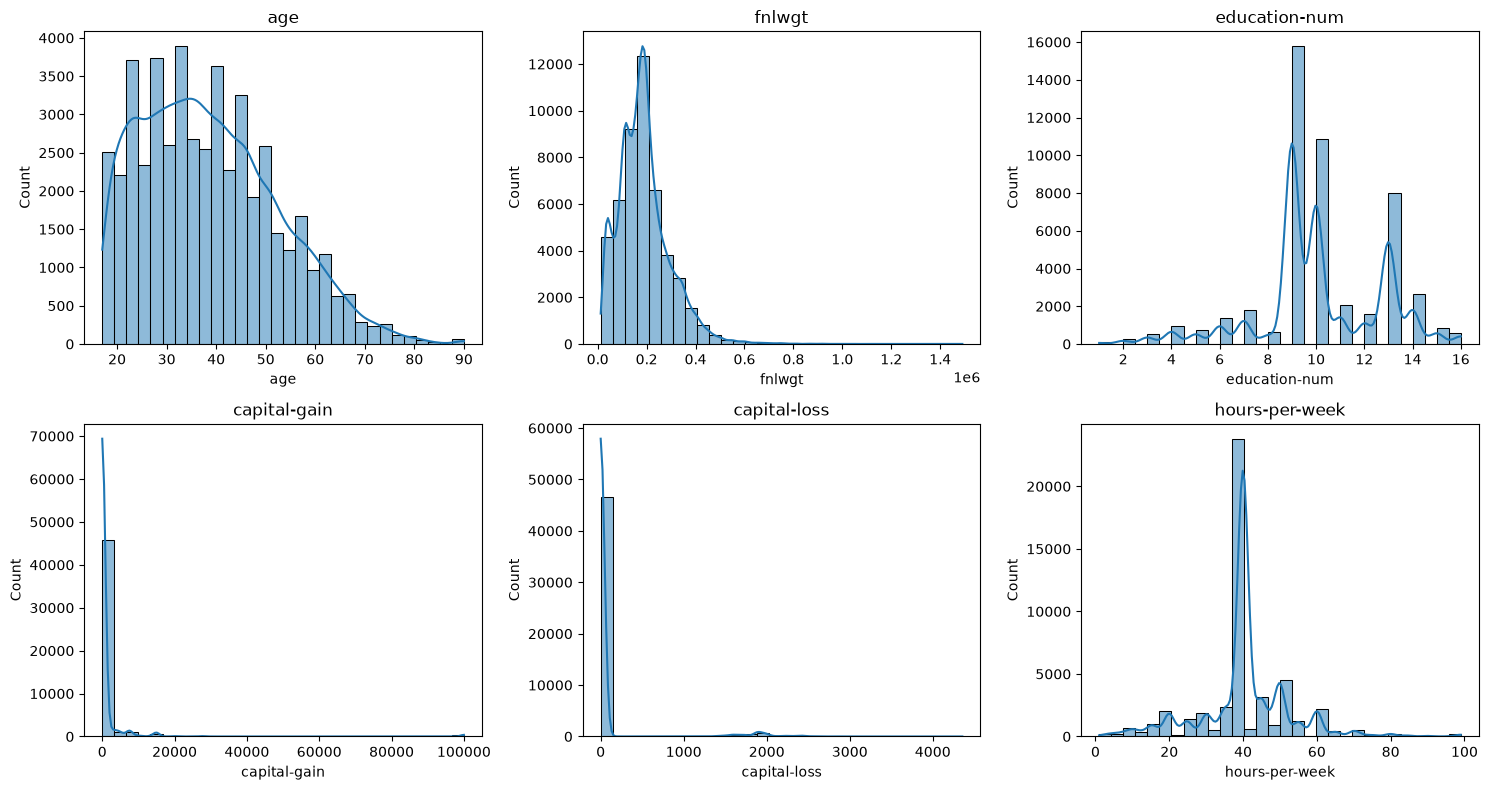

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_cuantitativas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Descripción de las variables cuantitativas:

- **age**: su rango va de 17 a 90 años, con un promedio de 38.6 y mediana 37, bastante cercanas, lo que indica una distribución razonablemente simétrica.

- **fnlwgt**: rango muy amplio (12.285 a 1.490.400) y media (189.664) bastante más alta que la mediana (178.144). Distribución asimétrica cesgada a la derecha (contiene valores extremos).

- **education-num**: A pesar de su baja cardinalidad, es una variable cuantitativa ordinal (no continua), su rango se extiende de 1 a 16 y esto nos genera un orden sobre el rango permitiendo considerar la escala educativa para predecir mediante calculos la generación de ingresos económicos . La media es 10.08 y la mediana 10, se comporta de manera simétrica. 

- **capital-gain**: el 91.7% de las personas tiene capital-gain igual a 0. La media (1079) está muy por encima de la mediana (0). Distribución asimétrica cesgada a la derecha. Importante confirmar que el valor máximo registrado es de 99,999 USD. Monto que puede ser mayor sin embargo el documento original así lo estableció. (contiene valores extremos) 

- **capital-loss**: 95.3% en cero, media 87.5 contra una mediana de 0. Distribución asimétrica cesgada a la derecha (contiene valores extremos).

- **hours-per-week**: es una variable con distribución bastante simétrica.

### 3.6.2 Estadística descriptiva de variables cualitativas:

Se identificaron 9 variables cualitativas a las cuales se les analizó las siguientes estadísticas: dato moda para cada variable cualitativa, la frecuencia absoluta, y cuánto representa el dato moda del total de registros de cada una de las variables. 

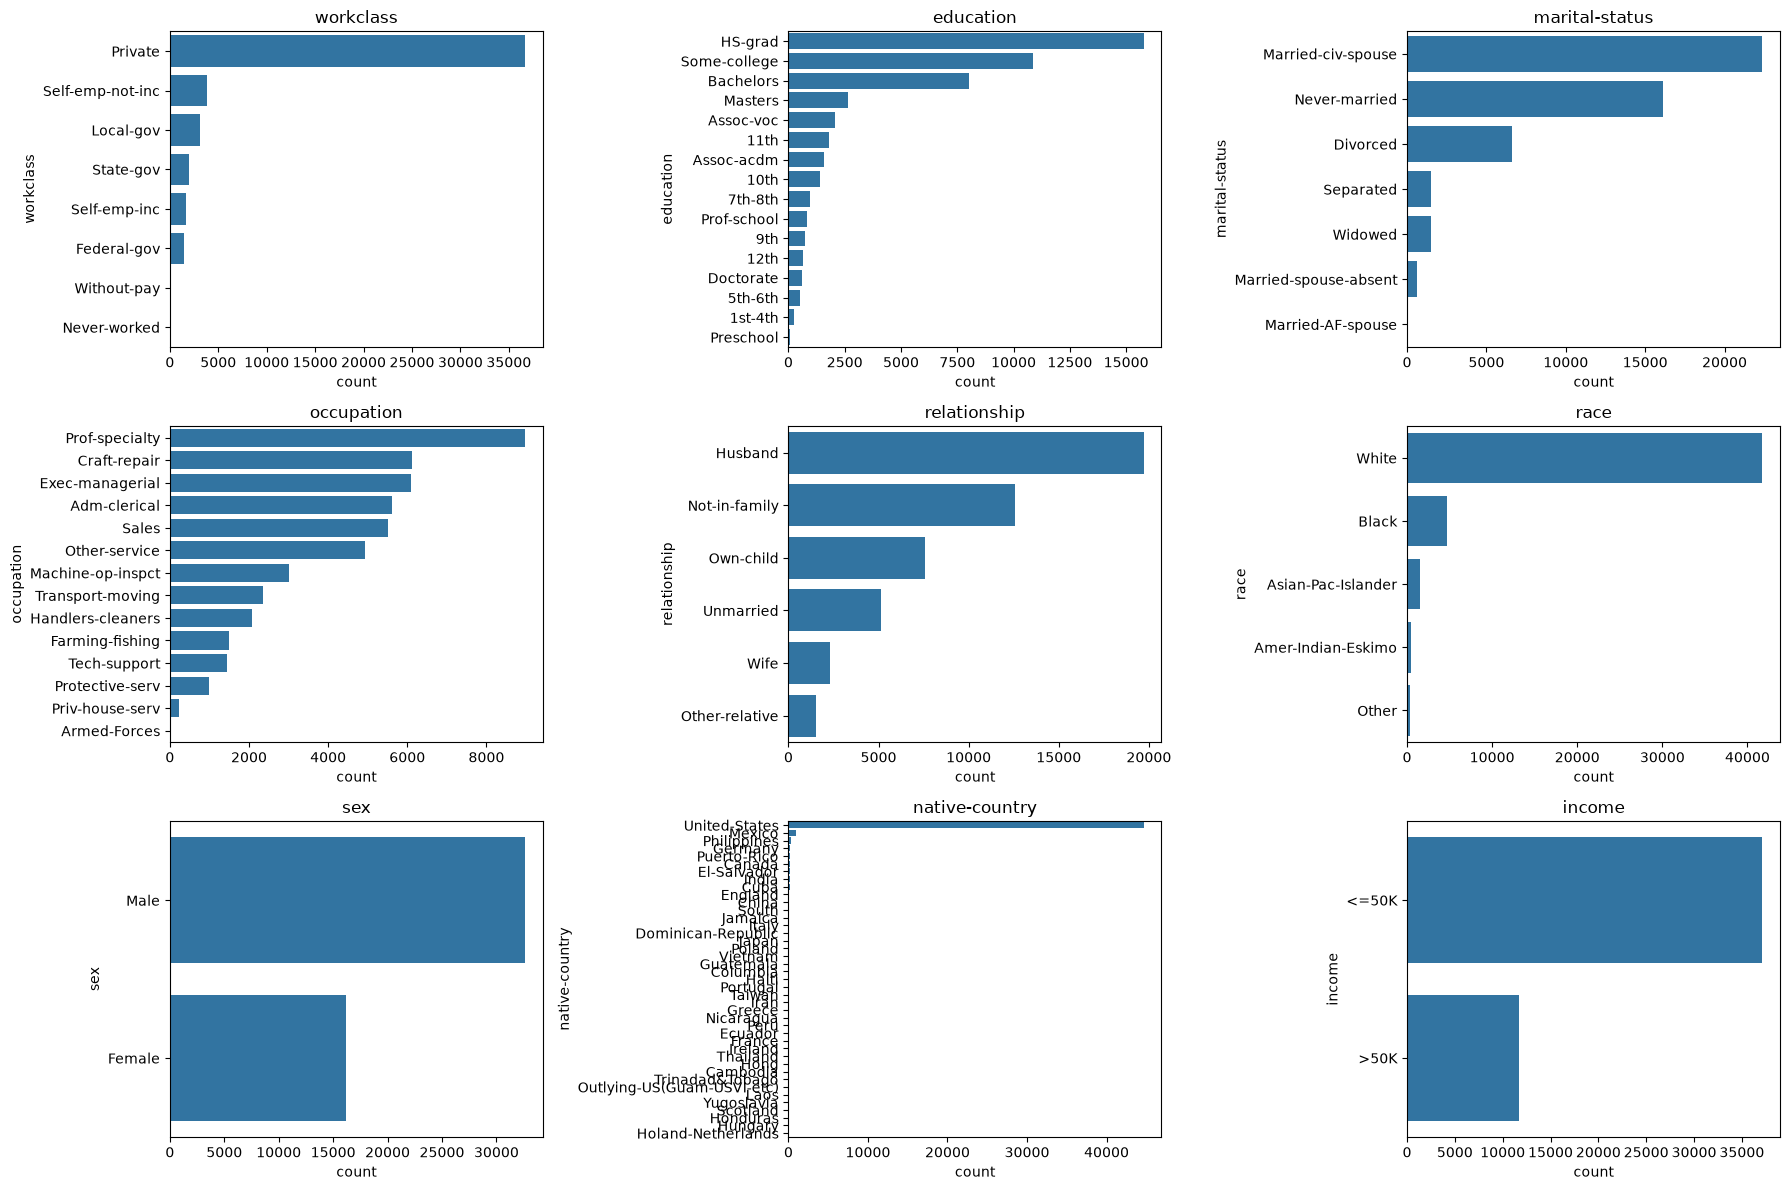

In [59]:
# Copia solo para mostrar sex/income con etiquetas legibles (no modifica df_clean)
df_display = df_clean.copy()
df_display['sex'] = df_display['sex'].map({0: 'Female', 1: 'Male'})
df_display['income'] = df_display['income'].map({0: '<=50K', 1: '>50K'})

vars_cualitativas = ['workclass', 'education', 'marital-status', 'occupation',
                      'relationship', 'race', 'sex', 'native-country', 'income']

# Tabla resumen
resumen_cat = df_display[vars_cualitativas].describe().T
resumen_cat['freq'] = pd.to_numeric(resumen_cat['freq'])
resumen_cat['count'] = pd.to_numeric(resumen_cat['count'])
resumen_cat

# Gráficos (vuelve a ser 3x3=9, ya no sobra ningún espacio)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    orden = df_display[col].value_counts().index
    sns.countplot(y=df_display[col], order=orden, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [60]:
# Copia solo para mostrar sex/income con etiquetas legibles (no modifica df_clean)
df_display = df_clean.copy()
df_display['sex'] = df_display['sex'].map({0: 'Female', 1: 'Male'})
df_display['income'] = df_display['income'].map({0: '<=50K', 1: '>50K'})

vars_cualitativas = ['workclass', 'education', 'marital-status', 'occupation',
                      'relationship', 'race', 'sex', 'native-country', 'income']

resumen_cat = df_display[vars_cualitativas].describe().T
resumen_cat['freq'] = pd.to_numeric(resumen_cat['freq'])
resumen_cat['count'] = pd.to_numeric(resumen_cat['count'])
resumen_cat['unique'] = pd.to_numeric(resumen_cat['unique'])
resumen_cat['% de la moda'] = (resumen_cat['freq'] / len(df_display) * 100).round(2)
resumen_cat

,count,unique,top,freq,% de la moda
workclass,48813,8,Private,36678,75.14
education,48813,16,HS-grad,15777,32.32
marital-status,48813,7,Married-civ-spouse,22372,45.83
occupation,48813,14,Prof-specialty,8976,18.39
relationship,48813,6,Husband,19709,40.38
race,48813,5,White,41736,85.50
sex,48813,2,Male,32631,66.85
native-country,48813,41,United-States,44666,91.50
income,48813,2,<=50K,37128,76.06


### Descripción de las estadísticas cualitativas por variable:


- **workclass**: 8 categorías, dominada 75.15% por "Private", es la categoría claramente mayoritaria del mundo laboral en EE.UU. de 1994. 

- **education**: 16 categorías, la moda es "HS-grad" con solo un 32.32% del total de registros.

- **marital-status**: 7 categorías, la moda fue "Married-civ-spouse" con 45.82% del total de registros. Casi la mitad de la población se encuentra formando parte de un matrimonio.

- **occupation**: 14 categorías, "Prof-specialty" es la moda con apenas un 18% del total de registros, es una variable categórica que se ha repartido de manera más equitativa.

- **relationship**: 6 categorías, la moda es: "Husband" 40%, casi la mitad de la población aproximadamente. 

- **race**: 5 categorías, "White" con 85.5% de la población encuestada en el año 1994 en Estados Unidos era de etnia blanca. 

- **sex**: categoría binaria, La moda fue "Male" 66.85% del total de personas.

- **native-country**: 41 categorías, dominada 91.5% por "United-States". El resto de los 41 países se reparten menos del 9%.

- **income**: categoría binaria, 76.07% de la población tiene un ingreso anual menor ó igual a los 50 mil dólares. 



# 3.7 Segunda Fase - Análisis de Estadística Descriptiva



- **Anomalías estadísticas:**  

- **Skewness:**

- **Valores extremos:**

- **Imbalance:**

- **Correlación excesiva:**

- **Leakage:**

- **Gaps temporales:**






## 3.7.1 Cardinalidad
- **Cualitativa:**  La cardinalidad  ó cantidad de categorías de cada variable, es indicada por la columna "unique" en la tabla anterior. (punto 3.6.2) 

- **Cuantitativa:** La indica la columna "rango" en la tabla anterior (punto 3.6.1)

In [40]:
todas_las_vars = vars_cuantitativas + vars_cualitativas

cardinalidad_total = df_clean[todas_las_vars].nunique().sort_values(ascending=False)
cardinalidad_total = pd.DataFrame({
    'cardinalidad': cardinalidad_total,
    '% del total de filas': (cardinalidad_total / len(df_clean) * 100).round(4),
    'tipo': ['cuantitativa' if c in vars_cuantitativas else 'cualitativa' for c in cardinalidad_total.index]
})
cardinalidad_total

,cardinalidad,% del total de filas,tipo
fnlwgt,28523,58.43,cuantitativa
capital-gain,123,0.25,cuantitativa
capital-loss,99,0.20,cuantitativa
hours-per-week,96,0.20,cuantitativa
age,74,0.15,cuantitativa
native-country,41,0.08,cualitativa
education-num,16,0.03,cuantitativa
education,16,0.03,cualitativa
occupation,14,0.03,cualitativa
workclass,8,0.02,cualitativa


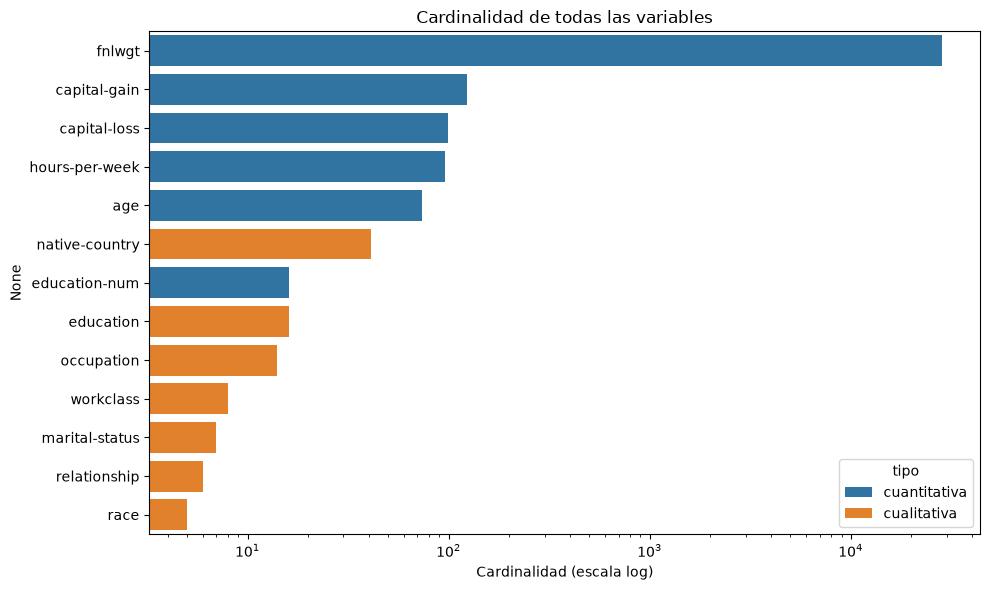

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cardinalidad_total['cardinalidad'], y=cardinalidad_total.index,
            hue=cardinalidad_total['tipo'], dodge=False)
plt.xscale('log')
plt.xlabel('Cardinalidad (escala log)')
plt.title('Cardinalidad de todas las variables')
plt.tight_layout()
plt.show()

El gráfico muestra las variables ordenadas de forma ascendente según la cantidad de categorías por cada una de las variables. Se utiliza una escala logarítmica para equiparar los rangos de las variables tanto cuantitativas como cualitativas.

Las variables cualitativas tienen una cardinalidad menor a las variables cuantitativas, lo cual facilita su clasificación. Las variables cuantitativas se podrían segmentizar (discretización) para reducir el número de categorías facilitando así su clasificación.

#### 3.7.2 Errores de Unidad
A. Se realizan 6 chequeos para las siguientes variables:

- 1. Revisión de tipos de datos actuales para variables cuantitativas
- 2. Valida la existencia de datos en formto decimal en variables cuantitativas
- 3. Confirma límite inferior en variable "capital-loss"
- 4. Confirma límite superior de rango en variable "age"
- 5. Confirma límite superior de rango en variable "hours-per-week"
- 6. Confirma límite superior de rango en variable "capital-gain"


In [42]:
# 1. El primero verifica que los tipos de datos correctos coincidan con lo que representan.
for col in vars_cuantitativas:
    print(f'{col}: dtype={df_clean[col].dtype}')

age: dtype=int64
fnlwgt: dtype=int64
education-num: dtype=int64
capital-gain: dtype=int64
capital-loss: dtype=int64
hours-per-week: dtype=int64


In [43]:
# 2. El segundo verifica que no haya valores con decimales donde se esperan números enteros. 

for col in vars_cuantitativas:
    con_decimales = (df_clean[col] % 1 != 0).sum()
    print(f'{col}: {con_decimales} filas con valores decimales')

age: 0 filas con valores decimales
fnlwgt: 0 filas con valores decimales
education-num: 0 filas con valores decimales
capital-gain: 0 filas con valores decimales
capital-loss: 0 filas con valores decimales
hours-per-week: 0 filas con valores decimales


In [44]:
# 3. El tercero confirma límite inferior de rango.

print('Filas con capital-loss = 4356 (posible tope de captura):', (df_clean['capital-loss'] == 4356).sum())

Filas con capital-loss = 4356 (posible tope de captura): 3


In [45]:
# 4. Confirma limite superior de rango en variable "age".
# 5. Confirma límite superior de rango en variable "hours-per-week". 

print('Filas con age = 90:', (df_clean['age'] == 90).sum())
print('Filas con hours-per-week = 99:', (df_clean['hours-per-week'] == 99).sum())

Filas con age = 90: 54
Filas con hours-per-week = 99: 137


In [46]:
# 6. Confirma límite superior de rango en variable: "capital-gain"

print('Filas con capital-gain = 99999 (posible limite de rango superior):', (df_clean['capital-gain'] == 99999).sum())

Filas con capital-gain = 99999 (posible limite de rango superior): 244


### Hallazgos de Errores de Unidad:

- Se confirma la inexistencia de tipos de datos nulos y flotantes en las variables cuantitativas.

- Se determina que las variables "capital-gain" y "capital-loss" se pueden trabajar como numeros enteros, facilita su clasificación y los decimales no agregan valor ni son relevantes.

- Se observan solamente 3 registros en variable "capital-loss" con un valor de 4,356 USD no obstante no se debe concluir que el 4,356 es un monto límite inferior establecido en el dataset original debido a que cuenta con muy pocos registros en esa categoría.

- La variable "capital-gain" muestra un tope superior por un valor de 99,999 USD y tienen 244 registros en esta categoría, lo cual indica que este límite superior del rango fue impuesto al momento de desarrollar el dataset. No obstante es probable que el monto original haya sido mayor a 99,999 USD.

- Las variables "age" y "hours-per-week" también muestran comportamiento como si tuviesen establecido un límite superior, la variable "age" tiene 55 registros con personas con 90 años exactos. La variable "hours-per-week" tiene 137 registros con personas que trabajan 99 horas a la semana. Siendo ambos casos imprecisos y muy posiblemente hayan registros con valores superiores en ambas categorías.


### 3.7.3 Anomalías Estadísticas

Se hace una revisión cruzada entre variables específicas con la finalidad de validar coherencia de los resultados obtenidos, para ello se cruzaron las siguientes variables:

- **workclass vrs hours-per-week:** se valida la categoría "Never-worked" tenga cero horas reportadas en la variable "hours-per-week".

- **capital-gain vrs capital-loss:** garantiza exclusividad sobre la variable que reporte saldo. Sería incoherente que ambas variables reporten saldos.

- **education vrs education-num:** confirma singularidad entre las categorías de las dos variables.

In [47]:
# 1. Never-worked debería tener hours-per-week = 0 (o muy bajo)
print('Never-worked con horas trabajadas:')
print(df_clean[df_clean['workclass'] == 'Never-worked']['hours-per-week'].describe())

Never-worked con horas trabajadas:
count   10.00
mean    28.90
std     13.08
min      4.00
25%     22.50
50%     35.00
75%     38.75
max     40.00
Name: hours-per-week, dtype: float64


In [48]:
# 2. ¿Alguna fila tiene capital-gain Y capital-loss mayores a 0 al mismo tiempo?
ambos = (df_clean['capital-gain'] > 0) & (df_clean['capital-loss'] > 0)
print(f'Filas con capital-gain Y capital-loss > 0 simultáneamente: {ambos.sum()}')
df_clean[ambos].head()

Filas con capital-gain Y capital-loss > 0 simultáneamente: 0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income


In [49]:
# 3. education vs education-num: cada texto de education debería mapear a un único número
mapeo = df_clean.groupby('education')['education-num'].nunique()
inconsistentes = mapeo[mapeo > 1]
print('Categorías de education con mapeo inconsistente:', inconsistentes.index.tolist() or 'ninguna')

Categorías de education con mapeo inconsistente: ninguna


### Hallazgos de Anomalías Estadísticas:

Se validan tres cruces de variables, tanto cuantitativas como cualitativas, con la finalidad de confirmar que los resultados en sus categorías sean matemáticamente coherentes. En los tres casos no se detectan incoherencias en cuánto a su lógica-matemática.



### 3.7.4 Skewness


Skewness ó Coeficiente de Asimetría nos indica que tan asimétrica es la distribución de los datos con respecto al promedio. Se aplica únicamente en variables cuantitativas.

In [50]:
skewness = df_clean[vars_cuantitativas].skew().sort_values(ascending=False)
skewness

capital-gain     11.89
capital-loss      4.57
fnlwgt            1.44
age               0.56
hours-per-week    0.24
education-num    -0.32
dtype: float64

### Hallazgos de Skewness:

Las variables **"capital-gain"**, con 11.89 puntos,  **"capital-loss"** con 4.57 puntos y **"fnlwgt"** con 1.44 puntos presentan una distribución de datos con asimetría positiva, más evidentemente en las primeras dos variables mencionadas puesto que son mucho mayores que el nivel de asimetría severo (igual a 1); las tres son candidatas a transformación (log1p u otra de mayor escala), mientras que las variables:  **"age"**, **"hours-per-week"** y **"education-num"** se pueden dejar tal como están.

### 3.7.5 Valores Extremos

Para identificar los valores extremos se usa el método IQR para la mayoría de variables cuantitativas, sin embargo hay dos variables a las cuales se les necesita aplicar un método alternativo debido a que en ambos casos más del 90% de los datos indican un mismo valor (0). Por tanto, el rango intercuartílico está cesgado, por ende se usa un percentil mayor para delimitar el cálculo e identificación de los valores extemos ó "outliers".

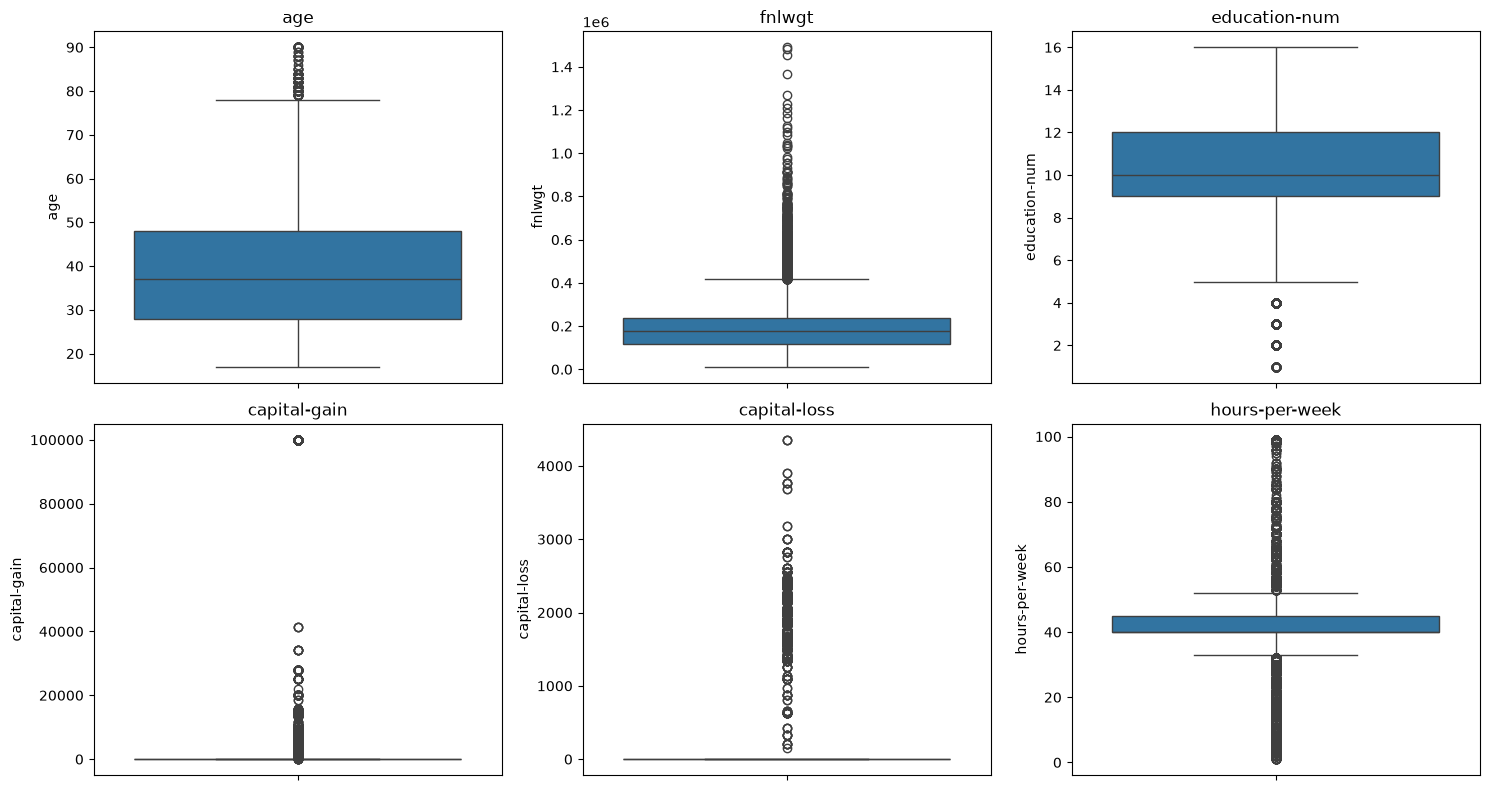

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_cuantitativas):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [52]:
for col in vars_cuantitativas:
    q1, q3 = df_clean[col].quantile(.25), df_clean[col].quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f'{col}: IQR={iqr}, rango válido=[{low}, {high}], outliers={n_out} ({n_out/len(df_clean)*100:.2f}%)')

age: IQR=20.0, rango válido=[-2.0, 78.0], outliers=215 (0.44%)
fnlwgt: IQR=120065.0, rango válido=[-62542.5, 417717.5], outliers=1453 (2.98%)
education-num: IQR=3.0, rango válido=[4.5, 16.5], outliers=1789 (3.67%)
capital-gain: IQR=0.0, rango válido=[0.0, 0.0], outliers=4035 (8.27%)
capital-loss: IQR=0.0, rango válido=[0.0, 0.0], outliers=2282 (4.67%)
hours-per-week: IQR=5.0, rango válido=[32.5, 52.5], outliers=13489 (27.63%)


In [53]:
# Rango de negocio para hours-per-week: el Census Bureau ya acota la variable a [1, 99] horas semanales
col = 'hours-per-week'
fuera_de_rango = ((df_clean[col] < 1) | (df_clean[col] > 99)).sum()
print(f'{col}: rango de negocio válido = [1, 99], filas fuera de rango = {fuera_de_rango} ({fuera_de_rango/len(df_clean)*100:.2f}%)')

hours-per-week: rango de negocio válido = [1, 99], filas fuera de rango = 0 (0.00%)


In [54]:
for col in ['capital-gain', 'capital-loss']:
    no_cero = df_clean[df_clean[col] > 0][col]
    p99 = no_cero.quantile(0.99)
    extremos = (no_cero > p99).sum()
    print(f'{col}: percentil 99 (entre no-ceros) = {p99}, {extremos} filas por encima de ese umbral')
    

capital-gain: percentil 99 (entre no-ceros) = 99999.0, 0 filas por encima de ese umbral
capital-loss: percentil 99 (entre no-ceros) = 2824.0, 18 filas por encima de ese umbral


In [55]:
#

for col in ['capital-gain', 'capital-loss']:
    no_cero = df_clean[df_clean[col] > 0][col]
    p99 = no_cero.quantile(0.99)
    valores_extremos = no_cero[no_cero > p99]
    extremos = len(valores_extremos)

    print(f'{col}:')
    print(f'  percentil 99 (entre no-ceros)   = {p99:,.0f}')
    print(f'  filas por encima de ese umbral  = {extremos}')

    # Si el percentil 99 coincide con el máximo, "por encima" da 0 siempre
    # (nadie puede superar un techo) -> se documenta como posible tope de captura
    if p99 == no_cero.max():
        en_maximo = (no_cero == no_cero.max()).sum()
        print(f'  -> el percentil 99 coincide con el máximo ({no_cero.max():,.0f}), probable tope de captura')
        print(f'  -> filas exactamente en ese máximo       = {en_maximo} ({en_maximo/len(no_cero)*100:.1f}% de los no-cero)')
    # Si sí hay filas por encima del umbral, se muestra qué valores concretos toman
    elif extremos > 0:
        print(f'  -> valores distintos por encima del umbral y su frecuencia:')
        for val, cnt in valores_extremos.value_counts().sort_index().items():
            print(f'       {int(val):>6,d}  ({cnt} filas)')
    print()

capital-gain:
  percentil 99 (entre no-ceros)   = 99,999
  filas por encima de ese umbral  = 0
  -> el percentil 99 coincide con el máximo (99,999), probable tope de captura
  -> filas exactamente en ese máximo       = 244 (6.0% de los no-cero)

capital-loss:
  percentil 99 (entre no-ceros)   = 2,824
  filas por encima de ese umbral  = 18
  -> valores distintos por encima del umbral y su frecuencia:
        3,004  (5 filas)
        3,175  (2 filas)
        3,683  (2 filas)
        3,770  (4 filas)
        3,900  (2 filas)
        4,356  (3 filas)



### Hallazgos de Valores Extremos

Se han identificado los valores extremos y su representación poblacional para cada variable, abajo los resultados:

| Variable         | IQR clásico | Método aplicado                  | Resultado final                        |
|---|---|---|---|
| age              | 0.44%       | IQR (sin corrección)             | 0.44% (216 filas)                      |
| fnlwgt           | 2.97%       | IQR (sin corrección)             | 2.97% (1,453 filas)                    |
| education-num    | 3.67%       | IQR (sin corrección)             | 3.67% (1,794 filas)                    |
| hours-per-week   | 27.63%      | Rango de negocio [1, 99]         | 0.00% (0 filas fuera de rango)         |
| capital-gain     | 8.26%       | Percentil 99 entre no-ceros      | 0.00% (0 filas; 244 en tope de captura)|
| capital-loss     | 4.67%       | Percentil 99 entre no-ceros      | 0.04% (18 filas)                       |


Con el IQR clásico, las variables age, fnlwgt y education-num muestran pocos outliers (entre 0.4% y 3.7%), mientras que hours-per-week marca 27.63%, pero es un falso positivo: casi todos trabajan 40 horas, así que el IQR queda muy angosto y se prioriza el rango de negocio (1-99) en su lugar. 

En capital-gain y capital-loss el IQR directamente no sirve, porque más del 90% de los valores son cero y eso deja el rango en [0,0]. Por eso se usa el percentil 99 solo entre los valores no-cero: en capital-gain ese percentil cae justo en 99999, el tope de captura del Census Bureau, **así que los 244 casos ahí no son outliers reales** sino un artefacto del dataset. 

En capital-loss sí aparecen 18 casos genuinos por encima del percentil 99, repartidos en varios montos, lo que indica pérdidas de capital reales. Ninguno de los dos se elimina, porque ambas variables se van a transformar con log1p más adelante.

La variable hours-per-week: rango de negocio válido = [1, 99], filas fuera de rango = 0 (0.00%) confirma que, aunque el IQR marca 27.63%, ningún valor está realmente fuera del rango físicamente posible.

Resumiendo, se fundamenta que las variables que deberán de ser transformadas son: "capital-gain", "capital-loss" y "fnlwgt". Se descarta de ser transformada la variable: "hours-per-week".









### 3.7.6 Imbalance

In [56]:
# Balance de la variable objetivo (income): 0 = <=50K, 1 = >50K
conteo = df_clean['income'].value_counts()
proporcion = df_clean['income'].value_counts(normalize=True).round(4) * 100
ratio = conteo.max() / conteo.min()

print('Conteo:')
print(conteo)
print('\nProporción (%):')
print(proporcion)
print(f'\nRatio mayoría:minoría = {ratio:.2f} : 1')

Conteo:
income
0    37128
1    11685
Name: count, dtype: int64

Proporción (%):
income
0   76.06
1   23.94
Name: proportion, dtype: float64

Ratio mayoría:minoría = 3.18 : 1


### Hallazgos de Imbalance:

- La variable objetivo income (0 = <=50K, 1 = >50K) presenta un desbalance moderado: 76.07% de los registros caen en la categoría 0 y 23.93% en la categoría 1, una relación de aproximadamente 3.18:1 entre la clase mayoritaria y la minoritaria.

- Se debe utilizar metricas de evaluación de modelos de predicción compatibles con las clases desbalanceadas (precisión, recall, F1 y AUC-ROC). 

- Se visualiza dividir el dataset en train/test usando stratify=y para preservar la proporción 76/24 en ambos conjuntos.

- Se considera el configurar en próximos pasos la opción ( classweight = 'balanced' ) para asignarle mayor puntaje al grupo minoritario debido es el grupo de mayor interés para esta investigación.



### 3.7.7 Correlación Excesiva

#### 3.7.7.1 Correlación Excesiva en Variables Cuantitativas:

- En estas sección se busca identificar aquellas correlaciones que se comportan con tal similitud que la información que ofrecen es redundante, por lo que se optará por descartarlas del entrenamiento del modelo y de los siguientes análisis. Al tratarse con variables cuantitativas se opta por el método nombrado **"Coeficiente de Correlación de Pearson"** para el cálculo de las correlaciones.

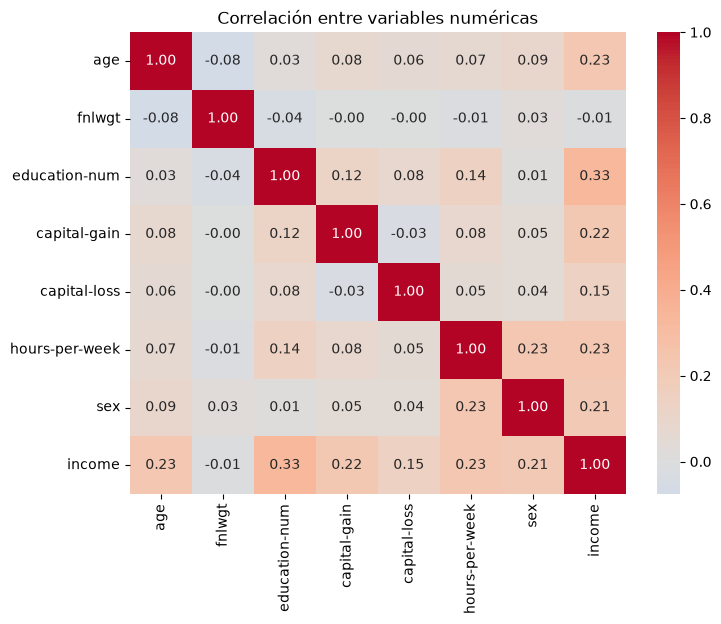

Pares con |r| > 0.5:
(si no se imprimió ningún par arriba, es porque ninguno superó el umbral)

Valores distintos de education-num por cada education: 1


In [57]:
# Coeficin

import itertools

num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'sex', 'income']
corr = df_clean[num_cols].corr().round(3)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas')
plt.show()

print('Pares con |r| > 0.5:')
for a, b in itertools.combinations(num_cols, 2):
    r = corr.loc[a, b]
    if abs(r) > 0.5:
        print(f'  {a} vs {b}: r={r}')
    else:
        pass
print('(si no se imprimió ningún par arriba, es porque ninguno superó el umbral)')

# Redundancia que NO aparece en la matriz numérica: education vs education-num
print('\nValores distintos de education-num por cada education:',
      df_clean.groupby('education')['education-num'].nunique().max())  # 1 = redundancia total

#### 3.7.7.1 Correlación excesiva en variables cualitativas:

Se utiliza la herramienta de cálculo de correlación **V de Cramér** se calcula a partir de una prueba de chi-cuadrado y da un valor entre 0 (sin asociación) y 1 (asociación total), es el equivalente conceptual del coeficiente de correlación, pero para variables categóricas.



In [58]:
from scipy.stats import chi2_contingency
import numpy as np
import itertools

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

vars_cualitativas = ['workclass', 'education', 'marital-status', 'occupation',
                      'relationship', 'race', 'sex', 'native-country']

resultados = []
for a, b in itertools.combinations(vars_cualitativas, 2):
    sub = df_clean[[a, b]].dropna()
    v = cramers_v(sub[a], sub[b])
    resultados.append((a, b, v))

resultados.sort(key=lambda x: -x[2])
for a, b, v in resultados[:8]:
    print(f'{a} vs {b}: V={v:.3f}')

relationship vs sex: V=0.647
marital-status vs relationship: V=0.488
marital-status vs sex: V=0.459
occupation vs sex: V=0.422
race vs native-country: V=0.398
workclass vs occupation: V=0.190
education vs occupation: V=0.171
occupation vs relationship: V=0.167


### Hallazgos de Correlación Excesiva en Variables Cuantitativas:

- Entre las variables predictoras numéricas (age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week, sex) no se encontró ningún par con correlación moderada ni excesiva.

- El valor más alto entre predictoras es apenas 0.14 (education-num vs. hours-per-week), muy por debajo del umbral de 0.5 considerado moderado y lejos del 0.8 que se consideraría multicolinealidad severa.

- Lo anterior significa que no hay redundancia estadística entre las variables numéricas del dataset.

- Respecto a income (la variable objetivo), las correlaciones más altas son con education-num (0.33), age (0.23), hours-per-week (0.23) y capital-gain (0.22). Se consideran relaciones entre moderadas y bajas.

- El único caso de redundancia real detectado no aparece en esta matriz porque involucra una variable de texto: education y education-num codifican exactamente la misma información (cada categoría de education mapea a un único valor de education-num), solo que en formatos distintos. Se decide utilizar únicamente education-num como feature en el modelado, descartando education, para no duplicar la misma señal dos veces.


### Hallazgos de Correlación Excesiva en Variables Cualitativas

- Aparecieron asociaciones más fuertes. La más alta fue relationship vs. sex (V=0.647), tiene sentido, porque categorías como "Husband"/"Wife" casi delatan el sexo de la persona. Le siguen marital-status vs. relationship (0.488), marital-status vs. sex (0.459), occupation vs. sex (0.435) y race vs. native-country (0.415). Ninguna llega a ser una duplicación perfecta, pero sí son asociaciones fuertes que conviene tener presentes al elegir qué variables incluir en el modelo, particularmente relationship y marital-status, que describen una dimensión muy similar (estado familiar/civil) desde ángulos distintos.

- education y education-num codifican exactamente la misma información (cada categoría de texto mapea a un único valor numérico), no es una correlación alta, es la misma variable en dos formatos. Se decide usar solo education-num como feature, descartando education.

- Hay evidencia de multicolinealidad severa que obligue a eliminar variables numéricas. Sí se identifican dos casos de redundancia entre cualitativas para tener en cuenta al modelar: education (descartar, se usa education-num) y la superposición conceptual entre relationship/marital-status/sex (no se descarta ninguna todavía, pero se documenta para revisar si aportan valor incremental real una vez que se pruebe el modelo, o si conviene quedarse con una sola de las tres).





### 3.7.8 Leakage

Se vuelve a hacer una examinación del conjunto de datos para buscar filas duplicadas.

In [61]:
# 1. Filas duplicadas exactas (deberían dar 0, ya que se eliminaron en 3.2)
print('Filas duplicadas exactas:', df_clean.duplicated().sum())

# 2. ¿Alguna variable determina el target de forma casi perfecta?
print('\n% de income según capital-gain > 0:')
print((pd.crosstab(df_clean['capital-gain'] > 0, df_clean['income'], normalize='index') * 100).round(2))

print('\n% de income según capital-loss > 0:')
print((pd.crosstab(df_clean['capital-loss'] > 0, df_clean['income'], normalize='index') * 100).round(2))

Filas duplicadas exactas: 24

% de income según capital-gain > 0:
income           0     1
capital-gain            
False        79.47 20.53
True         38.27 61.73

% de income según capital-loss > 0:
income           0     1
capital-loss            
False        77.35 22.65
True         49.87 50.13


In [62]:
filas_antes = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
filas_despues = df_clean.shape[0]
print(f'Filas eliminadas por duplicado exacto (post-imputación): {filas_antes - filas_despues}')
print(f'Filas totales luego de eliminar duplicados: {filas_despues}')

Filas eliminadas por duplicado exacto (post-imputación): 24
Filas totales luego de eliminar duplicados: 48789


In [63]:
# 1. Filas duplicadas exactas (deberían dar 0, ya que se eliminaron en 3.2)
print('Filas duplicadas exactas:', df_clean.duplicated().sum())

# 2. ¿Alguna variable determina el target de forma casi perfecta?
print('\n% de income según capital-gain > 0:')
print((pd.crosstab(df_clean['capital-gain'] > 0, df_clean['income'], normalize='index') * 100).round(2))

print('\n% de income según capital-loss > 0:')
print((pd.crosstab(df_clean['capital-loss'] > 0, df_clean['income'], normalize='index') * 100).round(2))

Filas duplicadas exactas: 0

% de income según capital-gain > 0:
income           0     1
capital-gain            
False        79.47 20.53
True         38.27 61.73

% de income según capital-loss > 0:
income           0     1
capital-loss            
False        77.34 22.66
True         49.87 50.13


### Hallazgos de Leakage

- Ninguna columna determina el valor de income de forma sospechosa o casi perfecta. capital-gain > 0 sube la probabilidad de income=1 (>50K) de 20.53% a 61.73%, y capital-loss > 0 la sube de 22.66% a 50.13% — señales fuertes, pero lejos de ser deterministas, por lo que se consideran features legítimas.


- Sobre el leakage de partición: los 48 duplicados originales detectados en 3.2 se habían eliminado antes de la imputación de nulos, pero ese mismo paso de imputación generó 24 duplicados nuevos (filas que antes diferían solo por tener un valor faltante en workclass, occupation o native-country, y que al imputarse con la moda quedaron idénticas a otra fila ya existente). Se detectaron y eliminaron en esta sección, confirmando df_clean.duplicated().sum() = 0.

- No se encontró evidencia de leakage por variables: ninguna columna determina el valor de income de forma sospechosa o casi perfecta. Se revisaron específicamente capital-gain y capital-loss, por ser las variables con mayor poder predictivo individual.

- No queda ninguna variable y categoría expuesta a riesgo de leakage por duplicación pendiente para el momento de dividir los datos en train/test.

# 4. Data Quality Gates automáticos

Estas reglas validan automáticamente el dataset limpio antes de dividir los datos y construir el pipeline de clasificación. Si al menos una regla crítica falla, el proceso se detiene para impedir que el modelo sea entrenado con datos no confiables.

In [ ]:
def ejecutar_data_quality_gates(data, target='income', minimum_rows=30000):
    """Valida la calidad del dataset y detiene el pipeline si alguna regla falla."""
    resultados = []

    def validar(nombre, condicion, detalle):
        resultados.append({
            'regla': nombre,
            'estado': 'APROBADA' if bool(condicion) else 'FALLIDA',
            'detalle': detalle
        })

    columnas_esperadas = {
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week',
        'native-country', target
    }

    # Gate 1: el esquema debe contener exactamente las columnas esperadas.
    faltantes = columnas_esperadas - set(data.columns)
    adicionales = set(data.columns) - columnas_esperadas
    validar(
        'Esquema de columnas',
        not faltantes and not adicionales,
        f'Faltantes: {sorted(faltantes) or "ninguna"}; adicionales: {sorted(adicionales) or "ninguna"}'
    )

    # Gate 2: cantidad mínima suficiente para continuar con el modelado.
    validar(
        'Cantidad mínima de filas',
        len(data) >= minimum_rows,
        f'{len(data):,} filas; mínimo requerido: {minimum_rows:,}'
    )

    # Gate 3: el dataset final no debe contener valores nulos.
    total_nulos = int(data.isna().sum().sum())
    validar('Ausencia de valores nulos', total_nulos == 0, f'{total_nulos} valores nulos')

    # Gate 4: tampoco deben quedar faltantes representados como texto.
    columnas_texto = data.select_dtypes(include=['object', 'string']).columns
    placeholders = {'?', '', 'NA', 'N/A', 'null', 'None'}
    total_placeholders = sum(
        int(data[col].astype('string').str.strip().isin(placeholders).sum())
        for col in columnas_texto
    )
    validar(
        'Ausencia de placeholders',
        total_placeholders == 0,
        f'{total_placeholders} valores faltantes representados como texto'
    )

    # Gate 5: no se permiten duplicados antes de separar train y test.
    duplicados = int(data.duplicated().sum())
    validar('Ausencia de duplicados', duplicados == 0, f'{duplicados} filas duplicadas')

    # Gate 6: income debe existir, no tener nulos y contener únicamente 0 y 1.
    clases_target = set(data[target].dropna().unique()) if target in data.columns else set()
    target_valido = target in data.columns and data[target].notna().all() and clases_target == {0, 1}
    validar(
        'Dominio de la variable objetivo',
        target_valido,
        f'Clases encontradas: {sorted(clases_target, key=str)}; esperadas: [0, 1]'
    )

    # Gate 7: valida rangos conocidos del dataset Adult.
    rangos = {
        'age': (17, 90),
        'fnlwgt': (1, None),
        'education-num': (1, 16),
        'capital-gain': (0, 99999),
        'capital-loss': (0, 4356),
        'hours-per-week': (1, 99)
    }
    fuera_de_rango = {}
    for columna, (minimo, maximo) in rangos.items():
        if columna not in data.columns:
            fuera_de_rango[columna] = 'columna ausente'
            continue
        mascara = data[columna].lt(minimo)
        if maximo is not None:
            mascara = mascara | data[columna].gt(maximo)
        if mascara.any():
            fuera_de_rango[columna] = int(mascara.sum())
    validar(
        'Rangos de negocio',
        not fuera_de_rango,
        f'Filas fuera de rango: {fuera_de_rango or "ninguna"}'
    )

    # Gate 8: cada nivel educativo debe corresponder a un único código numérico.
    if {'education', 'education-num'}.issubset(data.columns):
        mapeo_educacion = data.groupby('education')['education-num'].nunique()
        educacion_inconsistente = mapeo_educacion[mapeo_educacion != 1].index.tolist()
    else:
        educacion_inconsistente = ['columnas ausentes']
    validar(
        'Consistencia education / education-num',
        not educacion_inconsistente,
        f'Categorías inconsistentes: {educacion_inconsistente or "ninguna"}'
    )

    # Gate 9: ambas clases deben conservar una representación mínima del 10 %.
    proporciones = data[target].value_counts(normalize=True) if target in data.columns else pd.Series(dtype=float)
    proporcion_minoritaria = float(proporciones.min()) if len(proporciones) == 2 else 0.0
    validar(
        'Representación de la clase minoritaria',
        proporcion_minoritaria >= 0.10,
        f'Clase minoritaria: {proporcion_minoritaria:.2%}; mínimo requerido: 10.00%'
    )

    reporte = pd.DataFrame(resultados)
    display(reporte)

    reglas_fallidas = reporte.loc[reporte['estado'] == 'FALLIDA', 'regla'].tolist()
    if reglas_fallidas:
        raise ValueError(
            'DATA QUALITY GATES FALLIDOS. Se detiene el pipeline. '
            f'Reglas fallidas: {reglas_fallidas}'
        )

    print(f'DATA QUALITY APROBADO: {len(reporte)} de {len(reporte)} reglas superadas.')
    return reporte


reporte_data_quality = ejecutar_data_quality_gates(df_clean)

<!-- PIPELINE_DATOS_REUTILIZABLE_V1 -->
# Pipeline de Datos

# I. Feature Engineering

En las secciones anteriores se analizaron la calidad, distribución, cardinalidad, valores extremos, desbalance, correlación y posibles riesgos de *leakage* del dataset Adult Census Income.

El propósito de esta sección es convertir las decisiones obtenidas durante ese análisis en un **pipeline reproducible**, capaz de procesar de la misma forma los datos de entrenamiento, prueba y producción.

## Objetivo del pipeline

El pipeline integra las siguientes etapas:

1. Ingesta del dataset.
2. Normalización de valores faltantes y de la variable objetivo.
3. Ejecución de reglas automáticas de calidad.
4. Eliminación de filas duplicadas.
5. Separación estratificada entre entrenamiento y prueba.
6. Ingeniería de variables basada en los resultados del EDA.
7. Imputación, escalado y codificación aprendidos exclusivamente con entrenamiento.
8. Transformación del conjunto de prueba con los parámetros aprendidos en entrenamiento.
9. Persistencia del pipeline y de sus resultados.

La implementación se encuentra centralizada en `src/pipeline_datos.py`. Este notebook **no crea una segunda versión de las transformaciones**: importa el mismo código que deberá utilizarse para procesar datos nuevos en producción.


## I.1 Decisiones procedentes del análisis exploratorio

Las transformaciones implementadas no son arbitrarias. Cada una responde a un hallazgo documentado previamente:

| Hallazgo del análisis | Decisión implementada |
|---|---|
| Se encontraron representaciones `?`, espacios y valores nulos | Unificar todas las representaciones como faltantes reales |
| Se encontraron registros duplicados | Eliminarlos antes de separar train y test |
| `income` aparece como `<=50K`, `>50K` y con punto final en algunas filas | Normalizar y codificar el objetivo como 0 y 1 |
| Los faltantes se concentran en `workclass`, `occupation` y `native-country` | Imputar con la moda aprendida solamente en entrenamiento |
| La ausencia de información puede contener señal | Crear indicadores binarios de ausencia |
| `education` y `education-num` representan la misma información | Conservar `education-num` y eliminar `education` |
| `capital-gain` y `capital-loss` presentan más de 90% de ceros | Crear indicadores de presencia de ganancia o pérdida |
| `capital-gain`, `capital-loss` y `fnlwgt` tienen fuerte asimetría | Aplicar transformación `log1p` |
| Los extremos permanecen dentro de los rangos válidos del dataset | No eliminar observaciones únicamente por la regla del IQR |
| Existen categorías poco frecuentes | Agruparlas mediante el codificador ajustado con train |
| La clase objetivo presenta una relación aproximada de 76/24 | Realizar una partición estratificada |

### Decisión metodológica

La moda, las categorías del *one-hot encoding* y los parámetros del escalado se aprenden **después de la separación**, utilizando solamente `X_train`. Esto evita que información estadística del conjunto de prueba influya en la preparación de los datos de entrenamiento.


## I.2 Importación de la implementación reutilizable

El notebook se limita a configurar y ejecutar el pipeline. Toda la lógica se mantiene en el módulo Python para asegurar que el procesamiento aplicado durante el desarrollo sea idéntico al utilizado posteriormente en producción.


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pipeline_datos import (
    PipelineConfig,
    ejecutar_pipeline,
    transformar_nuevos_datos,
)


## I.3 Configuración reproducible

La semilla aleatoria se fija en 42 para reproducir la misma partición. Se reserva 20% de los datos para prueba y se mantiene la proporción original de la variable objetivo mediante `stratify`.

Las categorías que tengan menos de 100 observaciones en entrenamiento serán tratadas como categorías infrecuentes. Este límite se guarda como parte de la configuración y no se recalcula manualmente en el notebook.


In [ ]:
configuracion_pipeline = PipelineConfig(
    test_size=0.20,
    random_state=42,
    min_category_frequency=100,
    minimum_rows=30_000,
)

configuracion_pipeline


## I.4 Ejecución: ingesta, validación, limpieza y transformación

Si `resultado_pipeline/adult_raw.csv` ya existe, se utiliza como fuente local para que la ejecución sea repetible y no dependa de una nueva descarga. Si aún no existe, el pipeline obtiene el dataset desde el repositorio UCI y guarda una copia sin transformar.

Los resultados se almacenan en la carpeta `resultado_pipeline`.


In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "resultado_pipeline"
RAW_DATA_PATH = OUTPUT_DIR / "adult_raw.csv"

resultado_pipeline = ejecutar_pipeline(
    output_dir=OUTPUT_DIR,
    raw_path=RAW_DATA_PATH if RAW_DATA_PATH.exists() else None,
    config=configuracion_pipeline,
)

print("Pipeline ejecutado correctamente.")
print(f"Resultados guardados en: {resultado_pipeline['output_dir'].resolve()}")


## I.5 Validación del pipeline

Los *Data Quality Gates* se aplican en distintos momentos:

- **Raw:** verifica esquema, volumen, objetivo y rangos; permite los faltantes y duplicados esperados antes de limpiar.
- **Clean:** comprueba que los duplicados hayan sido eliminados y que la estructura siga siendo válida.
- **Transformed:** confirma que las matrices finales sean completamente numéricas y no contengan valores nulos ni infinitos.

Si una regla crítica falla, el pipeline se detiene y no guarda un modelo de transformación como si los datos fueran válidos.


In [ ]:
reporte_calidad_pipeline = resultado_pipeline["quality_report"]
display(reporte_calidad_pipeline)

resumen_gates = reporte_calidad_pipeline["estado"].value_counts()
print("Resumen de validaciones:")
display(resumen_gates.to_frame("cantidad"))


### Decisión resultante de las validaciones

El entrenamiento de modelos solamente podrá continuar cuando todas las reglas tengan estado `APROBADA`. Esta condición transforma las revisiones exploratorias del proyecto en controles automáticos y reutilizables.


## I.6 Resultados de limpieza y partición

El manifiesto registra la trazabilidad de la ejecución: dimensiones originales y finales, duplicados eliminados, configuración, proporción de la clase objetivo y nombres de los archivos generados.


In [ ]:
manifiesto_pipeline = resultado_pipeline["manifest"]

resumen_ejecucion = pd.DataFrame({
    "indicador": [
        "Dimensión original",
        "Dimensión después de eliminar duplicados",
        "Duplicados eliminados",
        "Dimensión de entrenamiento transformado",
        "Dimensión de prueba transformado",
        "Proporción >50K en entrenamiento",
        "Proporción >50K en prueba",
    ],
    "resultado": [
        str(tuple(manifiesto_pipeline["raw_shape"])),
        str(tuple(manifiesto_pipeline["clean_shape"])),
        manifiesto_pipeline["duplicates_removed"],
        str(tuple(manifiesto_pipeline["train_shape"])),
        str(tuple(manifiesto_pipeline["test_shape"])),
        f"{manifiesto_pipeline['target_rate_train']:.2%}",
        f"{manifiesto_pipeline['target_rate_test']:.2%}",
    ],
})

display(resumen_ejecucion)


### Interpretación

- La eliminación de duplicados se realiza antes del `train_test_split`, reduciendo el riesgo de que un mismo registro aparezca en entrenamiento y prueba.
- La proporción de personas con ingreso superior a 50K se mantiene prácticamente igual en ambos conjuntos gracias a la estratificación.
- Las matrices transformadas tienen el mismo número y orden de columnas, condición indispensable para entrenar y utilizar el modelo posteriormente.


In [ ]:
X_train_transformado = resultado_pipeline["X_train"]
X_test_transformado = resultado_pipeline["X_test"]
y_train = resultado_pipeline["y_train"]
y_test = resultado_pipeline["y_test"]

print("X_train:", X_train_transformado.shape)
print("X_test: ", X_test_transformado.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

assert list(X_train_transformado.columns) == list(X_test_transformado.columns)
assert X_train_transformado.isna().sum().sum() == 0
assert X_test_transformado.isna().sum().sum() == 0

display(X_train_transformado.head())


## I.7 Variables generadas

El pipeline produce tres tipos principales de variables:

1. **Numéricas escaladas:** edad, nivel educativo, horas por semana y transformaciones logarítmicas.
2. **Indicadores binarios:** presencia de ganancia/pérdida de capital y ausencia de información.
3. **Variables categóricas codificadas:** clase laboral, estado civil, ocupación, relación familiar, raza, sexo y país de origen.

`education` no se incluye porque duplica exactamente la información de `education-num`. Los valores originales de `fnlwgt`, `capital-gain` y `capital-loss` son sustituidos por sus versiones `log1p` dentro de la matriz destinada a modelos sensibles a escala.


In [ ]:
nombres_features = pd.DataFrame({
    "feature": X_train_transformado.columns,
})

print(f"Cantidad total de variables después de transformar: {len(nombres_features)}")
display(nombres_features)


## I.8 Persistencia de resultados

El pipeline guarda tanto datos intermedios como artefactos reutilizables:

| Archivo | Propósito |
|---|---|
| `adult_raw.csv` | Copia reproducible de los datos originales |
| `adult_clean.csv` | Datos normalizados y sin duplicados |
| `X_train_transformado.csv` | Predictores preparados para entrenamiento |
| `X_test_transformado.csv` | Predictores preparados para evaluación final |
| `y_train.csv`, `y_test.csv` | Variable objetivo de cada partición |
| `nombres_features.csv` | Orden exacto de las variables generadas |
| `reporte_calidad.csv` | Resultado de los Data Quality Gates |
| `pipeline_features.joblib` | Transformador ajustado que debe utilizar producción |
| `manifest.json` | Configuración y trazabilidad de la ejecución |


In [ ]:
archivos_pipeline = pd.DataFrame({
    "archivo": manifiesto_pipeline["artifacts"]
})
archivos_pipeline["existe"] = archivos_pipeline["archivo"].apply(
    lambda nombre: (OUTPUT_DIR / nombre).exists()
)
archivos_pipeline["ruta"] = archivos_pipeline["archivo"].apply(
    lambda nombre: str((OUTPUT_DIR / nombre).resolve())
)

display(archivos_pipeline)
assert archivos_pipeline["existe"].all()


## I.9 Uso del mismo pipeline con datos nuevos

En producción no se debe volver a calcular la moda, el escalado ni las categorías. Se carga `pipeline_features.joblib`, que conserva los parámetros aprendidos exclusivamente con entrenamiento.

La siguiente demostración toma cinco registros sin transformar y les aplica exactamente la misma lógica. En un escenario real, `datos_nuevos` provendría del sistema que solicita predicciones.


In [ ]:
datos_nuevos = pd.read_csv(OUTPUT_DIR / "adult_clean.csv").head(5)

datos_nuevos_transformados = transformar_nuevos_datos(
    data=datos_nuevos,
    pipeline_path=OUTPUT_DIR / "pipeline_features.joblib",
)

print("Dimensión de los datos nuevos transformados:", datos_nuevos_transformados.shape)
assert list(datos_nuevos_transformados.columns) == list(X_train_transformado.columns)
display(datos_nuevos_transformados)


## I.10 Conclusión de Feature Engineering

Las decisiones documentadas durante el EDA quedaron convertidas en un proceso automatizado, validado y persistente. La separación de responsabilidades es la siguiente:

- `Proyecto_Final_Mod6.ipynb` documenta los hallazgos, explica las decisiones y presenta los resultados.
- `src/pipeline_datos.py` contiene la única implementación de ingesta, limpieza y transformación.
- `resultado_pipeline/` conserva los datasets, reportes, configuración y el transformador ajustado.

De esta manera se evita mantener una lógica de Feature Engineering en el notebook y otra distinta en producción. El próximo pipeline de Machine Learning podrá consumir directamente `X_train`, `X_test`, `y_train` y `y_test`, sin repetir ninguna transformación.


# J. Modelado y experimentación

Esta sección fue trasladada al notebook independiente `J_Modelo_y_Experimentacion.ipynb`. Abra ese archivo y ejecute sus celdas en orden; no es necesario volver a ejecutar este notebook.